# Prática 3 - Clones

In [24]:
# Bibliotecas
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt

In [23]:
# Leitura dos dados
df = pd.read_parquet('../data/dados_clones.parquet')
df = df.set_index('p2o_master_id')
df.head()

,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses),Status
p2o_master_id,,,,,,,,
10578986,83.13,Yoda,180.25,Tipo 4,Tipo 1,Tipo 5,0.0,Defeituoso
10976676,83.08,Yoda,180.39,Tipo 3,Tipo 2,Tipo 5,0.0,Defeituoso
10588329,83.12,Shaak Ti,180.26,Tipo 4,Tipo 5,Tipo 5,0.0,Defeituoso
10254411,83.38,Shaak Ti,180.35,Tipo 2,Tipo 2,Tipo 5,0.0,Defeituoso
10634458,83.15,Shaak Ti,180.31,Tipo 3,Tipo 2,Tipo 2,0.0,Defeituoso


In [26]:
# Vamos verificar os valores unicos de cada coluna que contenha dados categóricos
print(df['General Jedi encarregado'].unique())
print(df['Distância Ombro a ombro'].unique())
print(df['Tamanho do crânio'].unique())
print(df['Tamanho dos pés'].unique())
print(df['Status '].unique())

<ArrowStringArray>
['Yoda', 'Shaak Ti', 'Obi-Wan Kenobi', 'Aayla Secura', 'Mace Windu']
Length: 5, dtype: str
<ArrowStringArray>
['Tipo 4', 'Tipo 3', 'Tipo 2', 'Tipo 1', 'Tipo 5']
Length: 5, dtype: str
<ArrowStringArray>
['Tipo 1', 'Tipo 2', 'Tipo 5', 'Tipo 3', 'Tipo 4']
Length: 5, dtype: str
<ArrowStringArray>
['Tipo 5', 'Tipo 2', 'Tipo 1', 'Tipo 3', 'Tipo 4']
Length: 5, dtype: str
<ArrowStringArray>
['Defeituoso', 'Apto']
Length: 2, dtype: str


In [27]:
# Transformando dados categóricos em numéricos
df['General Jedi encarregado'] = df['General Jedi encarregado'].replace({'Yoda': 1, 'Shaak Ti': 2, 'Obi-Wan Kenobi': 3, 'Aayla Secura': 4, 'Mace Windu': 5})
df['Distância Ombro a ombro'] = df['Distância Ombro a ombro'].replace({'Tipo 1': 1, 'Tipo 2': 2, 'Tipo 3': 3, 'Tipo 4': 4, 'Tipo 5': 5})
df['Tamanho do crânio'] = df['Tamanho do crânio'].replace({'Tipo 1': 1, 'Tipo 2': 2, 'Tipo 3': 3, 'Tipo 4': 4, 'Tipo 5': 5})
df['Tamanho dos pés'] = df['Tamanho dos pés'].replace({'Tipo 1': 1, 'Tipo 2': 2, 'Tipo 3': 3, 'Tipo 4': 4, 'Tipo 5': 5})

df.head()

,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses),Status
p2o_master_id,,,,,,,,
10578986,83.13,1,180.25,4,1,5,0.0,Defeituoso
10976676,83.08,1,180.39,3,2,5,0.0,Defeituoso
10588329,83.12,2,180.26,4,5,5,0.0,Defeituoso
10254411,83.38,2,180.35,2,2,5,0.0,Defeituoso
10634458,83.15,2,180.31,3,2,2,0.0,Defeituoso


In [28]:
# Separar features e target
features = df.drop('Status ', axis = 1)
target = df['Status ']

display(features.head())
display(target.head())

,Massa(em kilos),General Jedi encarregado,Estatura(cm),Distância Ombro a ombro,Tamanho do crânio,Tamanho dos pés,Tempo de existência(em meses)
p2o_master_id,,,,,,,
10578986,83.13,1,180.25,4,1,5,0.0
10976676,83.08,1,180.39,3,2,5,0.0
10588329,83.12,2,180.26,4,5,5,0.0
10254411,83.38,2,180.35,2,2,5,0.0
10634458,83.15,2,180.31,3,2,2,0.0


p2o_master_id
10578986    Defeituoso
10976676    Defeituoso
10588329    Defeituoso
10254411    Defeituoso
10634458    Defeituoso
Name: Status , dtype: str

In [29]:
# Aplicando o modelo de treinamento 
model = tree.DecisionTreeClassifier()

# Treinando o modelo
model.fit(X = features, y = target)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.7142857142857143, 0.9, 'Massa(em kilos) <= 83.405\ngini = 0.189\nsamples = 1048719\nvalue = [938193, 110526]\nclass = Apto'),
 Text(0.5714285714285714, 0.7, 'General Jedi encarregado <= 2.5\ngini = 0.436\nsamples = 344571\nvalue = [234045, 110526]\nclass = Apto'),
 Text(0.6428571428571428, 0.8, 'True  '),
 Text(0.42857142857142855, 0.5, 'Estatura(cm) <= 180.555\ngini = 0.485\nsamples = 188535\nvalue = [78009, 110526]\nclass = Defeituoso'),
 Text(0.2857142857142857, 0.3, 'Estatura(cm) <= 180.245\ngini = 0.28\nsamples = 132896\nvalue = [22370, 110526]\nclass = Defeituoso'),
 Text(0.14285714285714285, 0.1, '\n  (...)  \n'),
 Text(0.42857142857142855, 0.1, '\n  (...)  \n'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 55639\nvalue = [55639, 0]\nclass = Apto'),
 Text(0.7142857142857143, 0.5, 'gini = 0.0\nsamples = 156036\nvalue = [156036, 0]\nclass = Apto'),
 Text(0.8571428571428571, 0.7, 'gini = 0.0\nsamples = 704148\nvalue = [704148, 0]\nclass = Apto'),
 Text(0.7857142857

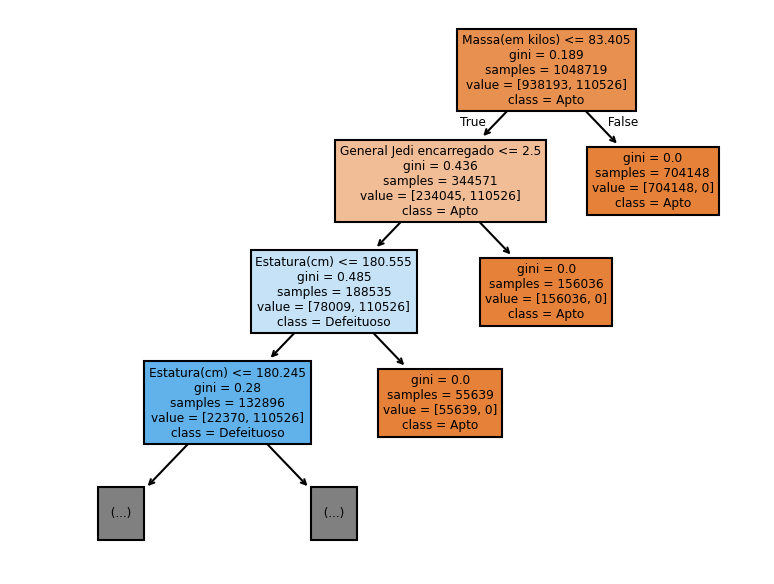

In [30]:
# Desenhando a árvore
plt.figure(dpi = 150)

tree.plot_tree(
    model,
    feature_names = features.columns,
    class_names = model.classes_,
    filled = True,
    max_depth = 3
)